Text(0.5, 1.0, 'Sixth Order Hill Function')

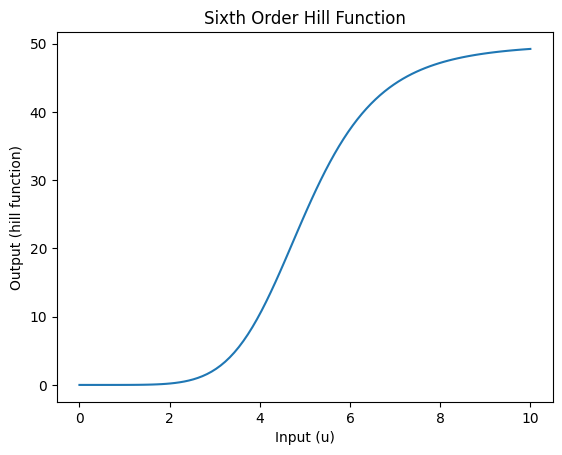

In [1]:
def hill_function(u, kd, n, max_production):
    return max_production * (u**n) / (kd**n + u**n)

from matplotlib import pyplot as plt
import numpy as np

u = np.linspace(0, 10, 100)
kd = 5.0
max_production = 50.0
hill_coefficient = 6.0

y = hill_function(u, kd, hill_coefficient, max_production)
plt.plot(u, y)
plt.xlabel('Input (u)')
plt.ylabel('Output (hill function)')
plt.title('Sixth Order Hill Function')

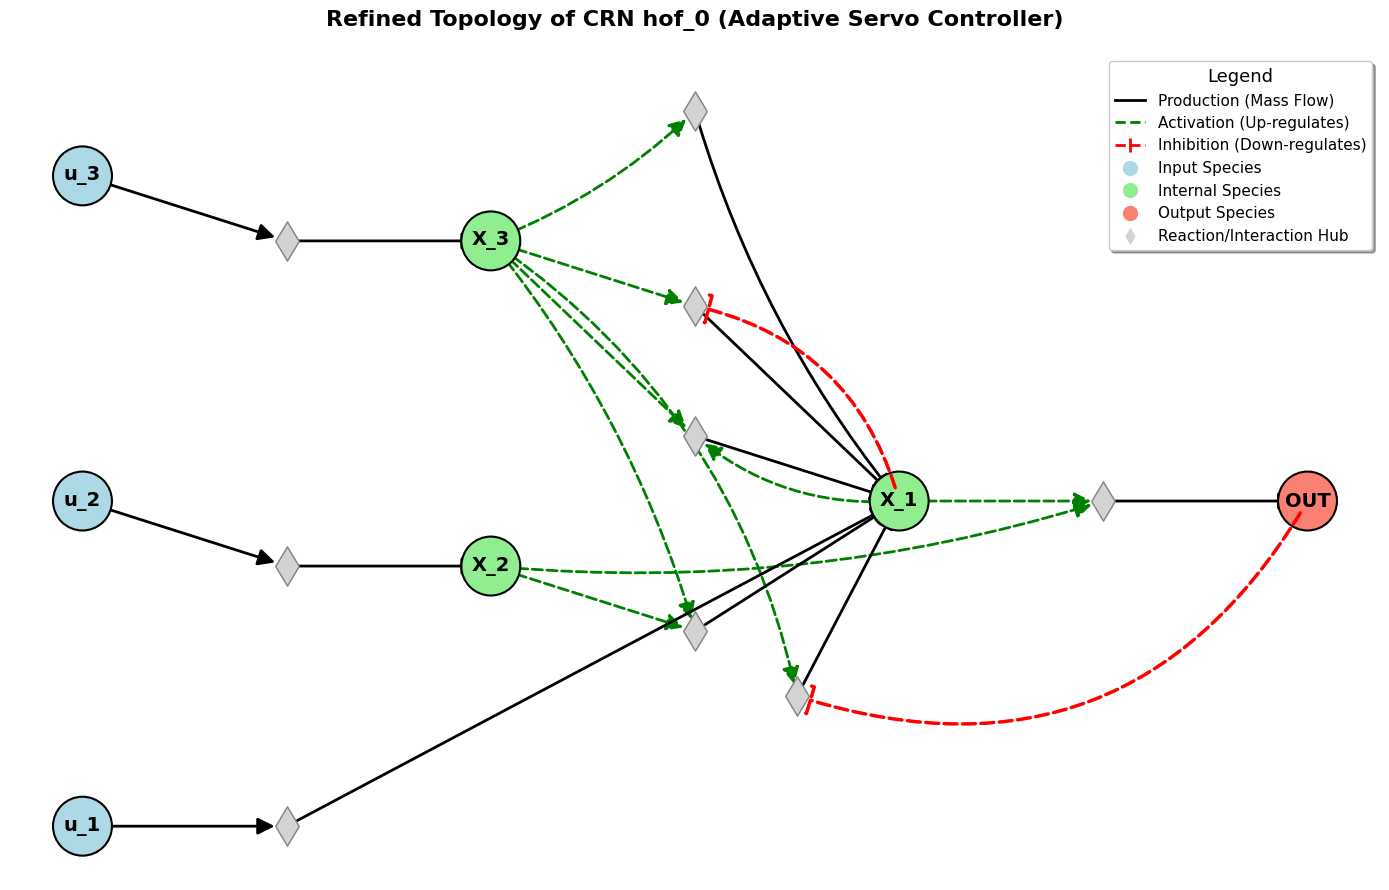

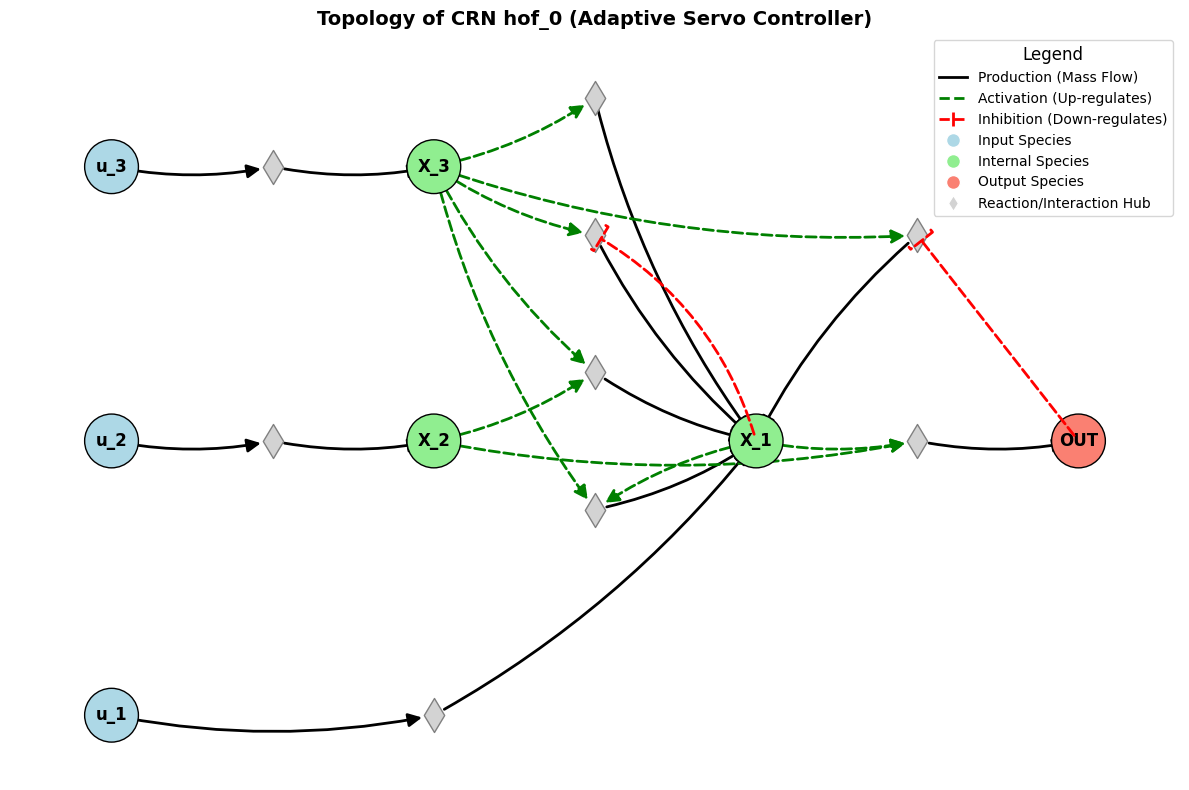

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_crn_topology():
    """
    Plots the topology of the specified Chemical Reaction Network (hof_0).
    """
    G = nx.MultiDiGraph()

    # --- Nodes ---
    # Species nodes with positions for a layered layout
    species = {
        'u_1': ((0, 1), 'lightblue', 'Input'),
        'u_2': ((0, 3), 'lightblue', 'Input'),
        'u_3': ((0, 5), 'lightblue', 'Input'),
        'X_3': ((2, 5), 'lightgreen', 'Internal'),
        'X_2': ((2, 3), 'lightgreen', 'Internal'),
        'X_1': ((4, 3), 'lightgreen', 'Internal (Hub)'),
        'OUT': ((6, 3), 'salmon', 'Output'),
    }

    for name, (pos, color, role) in species.items():
        G.add_node(name, pos=pos, color=color, label=name, role=role, shape='o', size=1500)

    # Reaction nodes (dummy nodes to represent complex Hill interactions)
    # Position them between their regulators and products
    reactions = {
        'R_u1': ((2, 1), 'Input -> X1'),
        'R_u2': ((1, 3), 'Input -> X2'),
        'R_u3': ((1, 5), 'Input -> X3'),
        'R_H0': ((3, 5.5), 'X3 -> X1'),
        'R_H1': ((3, 4.5), 'X3 -> X1 (inh X1)'),
        'R_H2': ((5, 4.5), 'X3 -> X1 (inh OUT)'),
        'R_H3': ((3, 2.5), 'X1, X3 -> X1'),
        'R_H4': ((3, 3.5), 'X2, X3 -> X1'),
        'R_H5': ((5, 3), 'X1, X2 -> OUT'),
    }
    for name, (pos, label) in reactions.items():
        G.add_node(name, pos=pos, color='lightgray', label='', role='Reaction', shape='d', size=300)


    # --- Edges ---
    edge_styles = {
        'production': {'color': 'black', 'style': '-', 'arrow': '-|>'},
        'activation': {'color': 'green', 'style': '--', 'arrow': '-|>'},
        'inhibition': {'color': 'red', 'style': '--', 'arrow': '-['},
    }

    edges = [
        # Input Production (MAK)
        ('u_1', 'R_u1', 'production'), ('R_u1', 'X_1', 'production'),
        ('u_2', 'R_u2', 'production'), ('R_u2', 'X_2', 'production'),
        ('u_3', 'R_u3', 'production'), ('R_u3', 'X_3', 'production'),

        # Hill Rxn 0: X3 -> X1
        ('X_3', 'R_H0', 'activation'), ('R_H0', 'X_1', 'production'),

        # Hill Rxn 1: X3 -> X1 (inh X1) - Internal Feedback
        ('X_3', 'R_H1', 'activation'), ('R_H1', 'X_1', 'production'),
        ('X_1', 'R_H1', 'inhibition'),

        # Hill Rxn 2: X3 -> X1 (inh OUT) - Output Feedback
        ('X_3', 'R_H2', 'activation'), ('R_H2', 'X_1', 'production'),
        ('OUT', 'R_H2', 'inhibition'),

        # Hill Rxn 3: X1, X3 -> X1 - Positive Feedback
        ('X_1', 'R_H3', 'activation'), ('X_3', 'R_H3', 'activation'),
        ('R_H3', 'X_1', 'production'),

        # Hill Rxn 4: X2, X3 -> X1
        ('X_2', 'R_H4', 'activation'), ('X_3', 'R_H4', 'activation'),
        ('R_H4', 'X_1', 'production'),

        # Hill Rxn 5: X1, X2 -> OUT - Final Gate
        ('X_1', 'R_H5', 'activation'), ('X_2', 'R_H5', 'activation'),
        ('R_H5', 'OUT', 'production'),
    ]

    for u, v, type in edges:
        G.add_edge(u, v, **edge_styles[type], type=type)


    # --- Drawing ---
    fig, ax = plt.subplots(figsize=(12, 8))
    pos = nx.get_node_attributes(G, 'pos')

    # Draw Species Nodes
    species_nodes = [n for n, d in G.nodes(data=True) if d['shape'] == 'o']
    node_colors = [G.nodes[n]['color'] for n in species_nodes]
    nx.draw_networkx_nodes(G, pos, nodelist=species_nodes, node_color=node_colors, node_shape='o', node_size=1500, edgecolors='black', linewidths=1, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in species_nodes}, font_size=12, font_weight='bold', ax=ax)

    # Draw Reaction Nodes
    reaction_nodes = [n for n, d in G.nodes(data=True) if d['shape'] == 'd']
    nx.draw_networkx_nodes(G, pos, nodelist=reaction_nodes, node_color='lightgray', node_shape='d', node_size=300, edgecolors='gray', linewidths=1, ax=ax)

    # Draw Edges by type for custom styling
    for type, style in edge_styles.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == type]
        if type == 'inhibition':
            # Manually draw inhibition edges to get the 'T' arrow
            for u, v in edgelist:
                # Calculate control points for a curved edge to avoid overlaps
                rad = 0.2 if u == 'X_1' and v == 'R_H1' else 0.0 # Curve self-loop
                
                # Use matplotlib's annotate for custom arrow styles
                ax.annotate("",
                            xy=pos[v], xycoords='data',
                            xytext=pos[u], textcoords='data',
                            arrowprops=dict(arrowstyle=style['arrow'],
                                            color=style['color'],
                                            linestyle=style['style'],
                                            linewidth=2,
                                            shrinkA=5, shrinkB=5,
                                            patchA=None, patchB=None,
                                            connectionstyle=f"arc3,rad={rad}"),
                            )
        else:
            # Standard drawing for other edges
            nx.draw_networkx_edges(G, pos, edgelist=edgelist, edge_color=style['color'], style=style['style'], arrowstyle=style['arrow'], width=2, arrowsize=20, ax=ax, connectionstyle="arc3,rad=0.1")


    # --- Legend and Layout ---
    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Production (Mass Flow)'),
        Line2D([0], [0], color='green', lw=2, ls='--', label='Activation (Up-regulates)'),
        Line2D([0], [0], color='red', lw=2, ls='--', marker='|', markersize=10, markeredgewidth=2, label='Inhibition (Down-regulates)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Input Species'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label='Internal Species'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=10, label='Output Species'),
        Line2D([0], [0], marker='d', color='w', markerfacecolor='lightgray', markersize=8, label='Reaction/Interaction Hub'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title="Legend", title_fontsize=12, frameon=True)

    ax.set_title("Topology of CRN hof_0 (Adaptive Servo Controller)", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    return fig

# Generate and display the plotimport matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
import numpy as np

def plot_refined_crn_topology():
    """
    Plots a refined, disentangled topology of the CRN hof_0.
    """
    G = nx.MultiDiGraph()

    # --- Nodes & Positions (Disentangled Layout) ---
    # Define positions in a grid-like structure for clarity
    # Columns: Inputs, Layer 1, Layer 2, Output
    # Rows: Spaced out to avoid overlap
    
    # Species
    species_pos = {
        'u_3': (0, 6), 'u_2': (0, 3.5), 'u_1': (0, 1),
        'X_3': (2, 5.5), 'X_2': (2, 3),
        'X_1': (4, 3.5),
        'OUT': (6, 3.5),
    }
    
    species_colors = {
        'u_1': 'lightblue', 'u_2': 'lightblue', 'u_3': 'lightblue',
        'X_1': 'lightgreen', 'X_2': 'lightgreen', 'X_3': 'lightgreen',
        'OUT': 'salmon',
    }
    
    for name, pos in species_pos.items():
        G.add_node(name, pos=pos, color=species_colors[name], shape='o', size=1800, label=name)

    # Reaction Hubs (Placed strategically to route edges)
    reaction_pos = {
        'R_u1': (1, 1), 'R_u2': (1, 3), 'R_u3': (1, 5.5),
        'R_H0_X3_X1': (3, 6.5),     # X3 -> X1 (Simple)
        'R_H1_X3_X1_inhX1': (3, 5), # X3 -> X1 (inh X1)
        'R_H2_X3_X1_inhOUT': (3.5, 2),# X3 -> X1 (inh OUT) - Route below
        'R_H3_X1X3_X1': (3, 4),     # X1, X3 -> X1 (Positive)
        'R_H4_X2X3_X1': (3, 2.5),   # X2, X3 -> X1
        'R_H5_X1X2_OUT': (5, 3.5),  # X1, X2 -> OUT (Final Gate)
    }
    for name, pos in reaction_pos.items():
        G.add_node(name, pos=pos, color='lightgray', shape='d', size=400, label='')

    # --- Edges & Styles ---
    edge_styles = {
        'production': {'color': 'black', 'style': '-', 'arrow': '-|>'},
        'activation': {'color': 'green', 'style': '--', 'arrow': '-|>'},
        'inhibition': {'color': 'red', 'style': '--', 'arrow': '-['},
    }

    edges = [
        # Input Production
        ('u_1', 'R_u1', 'production', 0), ('R_u1', 'X_1', 'production', 0),
        ('u_2', 'R_u2', 'production', 0), ('R_u2', 'X_2', 'production', 0),
        ('u_3', 'R_u3', 'production', 0), ('R_u3', 'X_3', 'production', 0),

        # H0: X3 -> X1
        ('X_3', 'R_H0_X3_X1', 'activation', 0.1), ('R_H0_X3_X1', 'X_1', 'production', 0.1),
        
        # H1: X3 -> X1 (inh X1) - Internal Negative Feedback
        ('X_3', 'R_H1_X3_X1_inhX1', 'activation', 0), ('R_H1_X3_X1_inhX1', 'X_1', 'production', 0),
        ('X_1', 'R_H1_X3_X1_inhX1', 'inhibition', 0.3), # Curve up and over

        # H2: X3 -> X1 (inh OUT) - Output Negative Feedback
        ('X_3', 'R_H2_X3_X1_inhOUT', 'activation', -0.2), # Route below X_2
        ('R_H2_X3_X1_inhOUT', 'X_1', 'production', 0),
        ('OUT', 'R_H2_X3_X1_inhOUT', 'inhibition', -0.4), # Long curve from OUT

        # H3: X1, X3 -> X1 - Positive Feedback
        ('X_3', 'R_H3_X1X3_X1', 'activation', 0), 
        ('X_1', 'R_H3_X1X3_X1', 'activation', -0.2), # Curve back
        ('R_H3_X1X3_X1', 'X_1', 'production', 0),

        # H4: X2, X3 -> X1
        ('X_2', 'R_H4_X2X3_X1', 'activation', 0), ('X_3', 'R_H4_X2X3_X1', 'activation', -0.1),
        ('R_H4_X2X3_X1', 'X_1', 'production', 0),

        # H5: X1, X2 -> OUT (Final Gate)
        ('X_1', 'R_H5_X1X2_OUT', 'activation', 0), ('X_2', 'R_H5_X1X2_OUT', 'activation', 0.1),
        ('R_H5_X1X2_OUT', 'OUT', 'production', 0),
    ]

    for u, v, type, rad in edges:
        G.add_edge(u, v, type=type, rad=rad, **edge_styles[type])

    # --- Drawing ---
    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.get_node_attributes(G, 'pos')

    # Draw Nodes
    species_nodes = [n for n, d in G.nodes(data=True) if d['shape'] == 'o']
    node_colors = [G.nodes[n]['color'] for n in species_nodes]
    nx.draw_networkx_nodes(G, pos, nodelist=species_nodes, node_color=node_colors, node_shape='o', node_size=1800, edgecolors='black', linewidths=1.5, ax=ax)
    
    reaction_nodes = [n for n, d in G.nodes(data=True) if d['shape'] == 'd']
    nx.draw_networkx_nodes(G, pos, nodelist=reaction_nodes, node_color='lightgray', node_shape='d', node_size=400, edgecolors='gray', linewidths=1, ax=ax)

    # Draw Labels
    nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in species_nodes}, font_size=14, font_weight='bold', ax=ax)

    # Draw Edges with custom curves and styles
    for u, v, data in G.edges(data=True):
        style = edge_styles[data['type']]
        rad = data['rad']
        
        # Calculate connection style
        connection_style = f"arc3,rad={rad}"

        # Manually draw arrows to control T-bars for inhibition
        if data['type'] == 'inhibition':
             ax.annotate("",
                        xy=pos[v], xycoords='data',
                        xytext=pos[u], textcoords='data',
                        arrowprops=dict(arrowstyle=style['arrow'],
                                        color=style['color'],
                                        linestyle=style['style'],
                                        linewidth=2.5,
                                        shrinkA=10, shrinkB=10,
                                        connectionstyle=connection_style),
                        )
        else:
            # Use NetworkX for standard arrows
             nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                                   edge_color=style['color'],
                                   style=style['style'],
                                   arrowstyle=style['arrow'],
                                   width=2, arrowsize=25,
                                   connectionstyle=connection_style,
                                   ax=ax)

    # --- Legend & Titles ---
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Production (Mass Flow)'),
        Line2D([0], [0], color='green', lw=2, ls='--', label='Activation (Up-regulates)'),
        Line2D([0], [0], color='red', lw=2, ls='--', marker='|', markersize=10, markeredgewidth=2, label='Inhibition (Down-regulates)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=12, label='Input Species'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=12, label='Internal Species'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=12, label='Output Species'),
        Line2D([0], [0], marker='d', color='w', markerfacecolor='lightgray', markersize=10, label='Reaction/Interaction Hub'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11, title="Legend", title_fontsize=13, frameon=True, shadow=True)

    ax.set_title("Refined Topology of CRN hof_0 (Adaptive Servo Controller)", fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()

    return fig

# Generate and display the refined plot
fig_refined = plot_refined_crn_topology()
plt.show()
fig = plot_crn_topology()
plt.show()